In [1]:
import sys, os
sys.path.insert(0, '../../')
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt 
from gasp import load_dataset

import logging
logging.getLogger('gasp.dataset').setLevel(logging.DEBUG)
logging.basicConfig() 

In [2]:
ds = {
    'path':'2025_10_1_sphere_phantom',
    'filter':'_fa60_'
}
M = load_dataset(**ds, )

ds_fieldmap = { 
    'path':'2025_10_1_sphere_phantom',
    'filter': 'gre_field_mapping',
    'description': 'GRE field mapping with TE1 = 4.92ms and TE2 = 7.38ms'
}
M_fieldmap = load_dataset(**ds_fieldmap)

ds_dixon = {
    'path':'2025_10_1_sphere_phantom',
    'filter': ['_gre_TE3p41', '_gre_TE4p55', '_gre_TE5p68']
}
M_dixon = load_dataset(**ds_dixon)

print('M shape: ', M.shape)
print('M_fieldmap shape: ', M_fieldmap.shape)
print('M_dixon shape: ', M_dixon.shape)

DEBUG:gasp.dataset:Filter: _fa60_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID231_bSSFP_gasp_knee_fa60_TR7ms_FID84860.dat', 'meas_MID232_bSSFP_gasp_knee_fa60_TR14ms_FID84861.dat', 'meas_MID233_bSSFP_gasp_knee_fa60_TR28ms_FID84862.dat']


pymapVBVD version 0.5.6
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/133M [00:00<?, ?B/s]

read data:   0%|          | 0/4096 [00:00<?, ?it/s]

pymapVBVD version 0.5.6
Software version: VB


...

read data:   0%|          | 0/64 [00:00<?, ?it/s]

pymapVBVD version 0.5.6
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

M shape:  (256, 256, 8, 16, 3)
M_fieldmap shape:  (128, 128, 8, 2, 1)
M_dixon shape:  (64, 64, 8, 3)


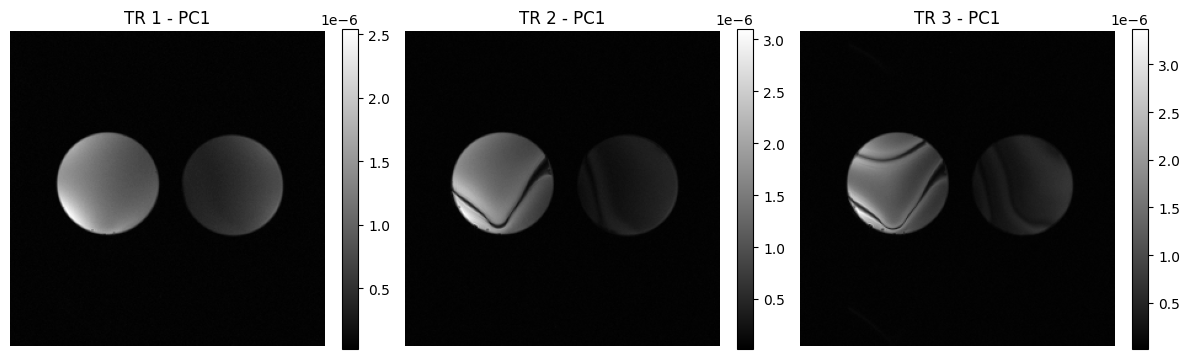

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# M shape: (Height, Width, Coil, PCs, TRs)
# Combine coils using root sum of squares (optimal for magnitude)
M_rss = np.sqrt(np.sum(np.abs(M)**2, axis=2))  # shape: (H, W, PCs, TRs)

# Extract first PC (index 0) for all 3 TRs
first_pc = M_rss[:, :, 0, :]  # shape: (H, W, TRs)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(np.abs(first_pc[:, :, i]), cmap='gray')
    axes[i].set_title(f'TR {i+1} - PC1')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

Original fieldmap shape: (128, 128)
Interpolated fieldmap shape: (256, 256)
Fieldmap range: -300.0 to 283.7 Hz


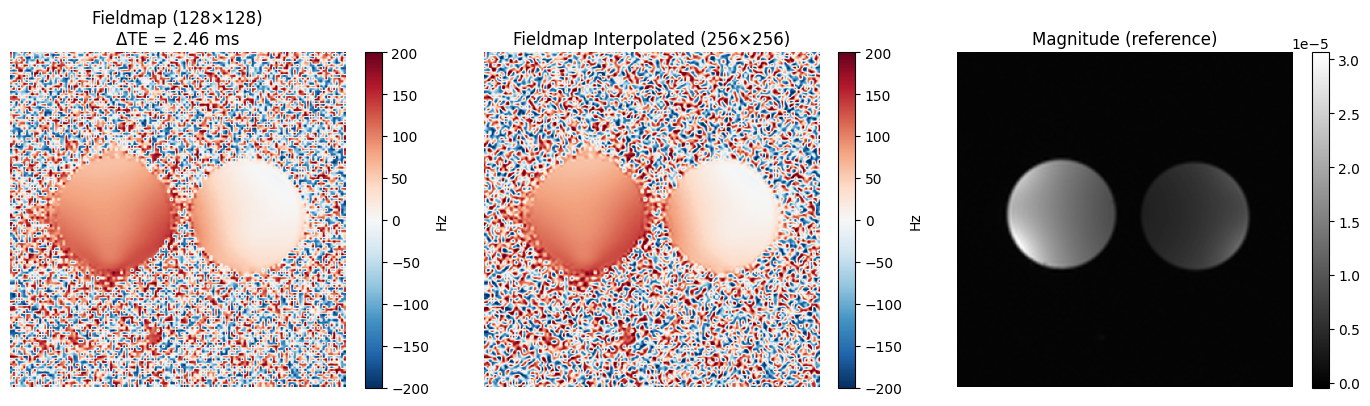

In [4]:
from scipy.ndimage import zoom

# M_fieldmap shape: (128, 128, 8, 2, 1) - (H, W, Coils, Echoes, TRs)
# TE1 = 4.92ms, TE2 = 7.38ms
TE1 = 4.92e-3  # seconds
TE2 = 7.38e-3  # seconds
delta_TE = TE2 - TE1  # 2.46 ms

# Combine coils using root sum of squares for magnitude-weighted phase
M_fm_te1 = M_fieldmap[:, :, :, 0, 0]  # (128, 128, 8)
M_fm_te2 = M_fieldmap[:, :, :, 1, 0]  # (128, 128, 8)

# Coil-combined phase difference (magnitude-weighted)
# Weight by magnitude to reduce noise in low-signal regions
magnitude = np.sqrt(np.sum(np.abs(M_fm_te1)**2 + np.abs(M_fm_te2)**2, axis=2))
phase_diff_per_coil = np.angle(M_fm_te2 * np.conj(M_fm_te1))

# Weighted average of phase difference across coils
weights = np.abs(M_fm_te1) * np.abs(M_fm_te2)
phase_diff = np.angle(np.sum(M_fm_te2 * np.conj(M_fm_te1), axis=2))

# Convert phase difference to Hz
fieldmap_hz = phase_diff / (2 * np.pi * delta_TE)

# Interpolate to match M dimensions (256, 256)
target_shape = M.shape[:2]  # (256, 256)
zoom_factors = (target_shape[0] / fieldmap_hz.shape[0], 
                target_shape[1] / fieldmap_hz.shape[1])
fieldmap_hz_interp = zoom(fieldmap_hz, zoom_factors, order=3)

print(f"Original fieldmap shape: {fieldmap_hz.shape}")
print(f"Interpolated fieldmap shape: {fieldmap_hz_interp.shape}")
print(f"Fieldmap range: {fieldmap_hz_interp.min():.1f} to {fieldmap_hz_interp.max():.1f} Hz")

# Plot original and interpolated fieldmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(fieldmap_hz, cmap='RdBu_r', vmin=-200, vmax=200)
axes[0].set_title(f'Fieldmap (128×128)\nΔTE = {delta_TE*1e3:.2f} ms')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Hz', fraction=0.046)

im1 = axes[1].imshow(fieldmap_hz_interp, cmap='RdBu_r', vmin=-200, vmax=200)
axes[1].set_title(f'Fieldmap Interpolated (256×256)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Hz', fraction=0.046)

# Show magnitude for reference
im2 = axes[2].imshow(zoom(magnitude, zoom_factors, order=3), cmap='gray')
axes[2].set_title('Magnitude (reference)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

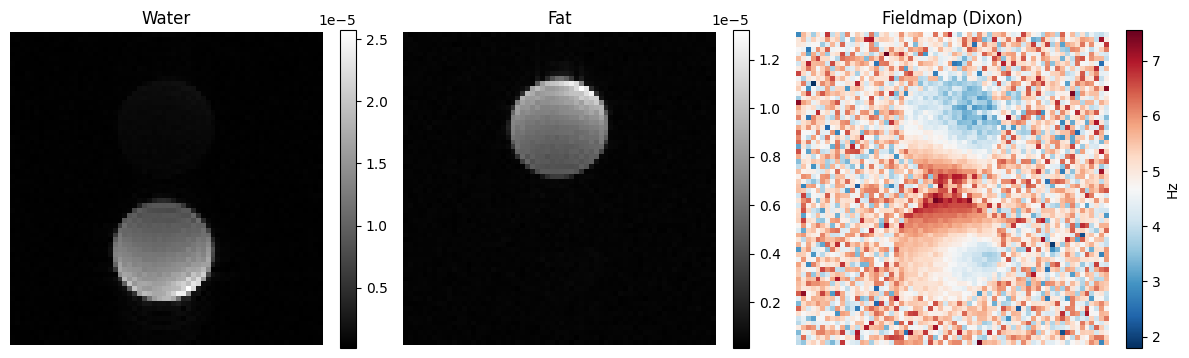

In [5]:
from gasp.analysis import dixon_3pt

Mwater, Mfat, field_map = dixon_3pt(M_dixon)

# Plot water, fat, and fieldmap in 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(Mwater, cmap='gray')
axes[0].set_title('Water')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Mfat, cmap='gray')
axes[1].set_title('Fat')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(field_map, cmap='RdBu_r')
axes[2].set_title('Fieldmap (Dixon)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='Hz', fraction=0.046)

plt.tight_layout()
plt.show()

Fat phase shift (fraction of period): 0.160
Water profile shape: (16,)
Fat profile shape: (16,)


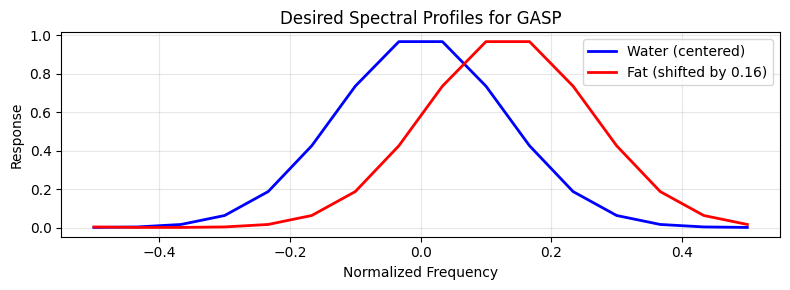

In [6]:
# GASP Water/Fat Separation with Fieldmap Compensation
from gasp import responses, ssfp
from gasp.fieldmap import FieldMapDictionary, train_fieldmap_dictionary, apply_gasp_with_fieldmap
from gasp.gasp import train_gasp

# Acquisition parameters for _fa60_ data
TRs = np.array([7e-3, 14e-3, 28e-3])  # 7ms, 14ms, 28ms
TEs = TRs / 2  # Assume TE = TR/2 for bSSFP
alpha = np.deg2rad(60)  # 60 degree flip angle
npcs = 16  # Number of phase cycles
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Tissue parameters for simulation (approximate phantom values)
T1_sim = 0.5  # seconds
T2_sim = 0.1  # seconds

# Fat chemical shift at 3T: ~3.5 ppm = ~440 Hz
fat_shift_hz = 440  # Hz

# Create spectral profiles for water and fat
# Profile width should match the number of phase cycles
profile_width = npcs

# Water bandpass - centered at 0 Hz (shift=0)
D_water = responses.bandpass(profile_width, bw=0.3, shift=0, type='gaussian')

# Fat bandpass - need to calculate shift based on TR
# For each TR, fat appears at: fat_shift_hz * TR (as fraction of 2*pi cycle)
# We'll use the middle TR (14ms) as reference
# Normalized shift: fat_shift_hz * TR = 440 * 0.014 = 6.16 radians = ~0.98 cycles
# Since bSSFP is periodic, fat at 440 Hz with TR=14ms appears at 440*0.014 mod 1 ≈ 0.16 of a cycle
fat_phase_shift = (fat_shift_hz * TRs[1]) % 1  # Fraction of spectral period
D_fat = responses.bandpass(profile_width, bw=0.3, shift=fat_phase_shift, type='gaussian')

print(f"Fat phase shift (fraction of period): {fat_phase_shift:.3f}")
print(f"Water profile shape: {D_water.shape}")
print(f"Fat profile shape: {D_fat.shape}")

# Plot the spectral profiles
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
freq_axis = np.linspace(-0.5, 0.5, profile_width)
ax.plot(freq_axis, D_water, 'b-', label='Water (centered)', linewidth=2)
ax.plot(freq_axis, D_fat, 'r-', label=f'Fat (shifted by {fat_phase_shift:.2f})', linewidth=2)
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Response')
ax.set_title('Desired Spectral Profiles for GASP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Train fieldmap dictionaries for water and fat using simulated SSFP signals
# We'll use a single TR first (TR=14ms as middle ground)

TR_idx = 1  # Use TR=14ms
TR = TRs[TR_idx]
TE = TEs[TR_idx]

# Create T1/T2 maps for training (uniform for simulation)
H, W = M.shape[:2]
T1_map = np.ones((H, W)) * T1_sim
T2_map = np.ones((H, W)) * T2_sim
alpha_map = np.ones((H, W)) * alpha

# Field map range based on measured fieldmap
fm_min, fm_max = fieldmap_hz_interp.min(), fieldmap_hz_interp.max()
field_range = (max(fm_min - 20, -200), min(fm_max + 20, 200))
n_bins = 31

print(f"Training fieldmap dictionary...")
print(f"  TR = {TR*1e3:.1f} ms, TE = {TE*1e3:.1f} ms")
print(f"  Flip angle = {np.rad2deg(alpha):.0f}°")
print(f"  Phase cycles = {npcs}")
print(f"  Field range: {field_range[0]:.0f} to {field_range[1]:.0f} Hz")
print(f"  Number of bins: {n_bins}")

# Train water dictionary
print("\nTraining water dictionary...")
dict_water = train_fieldmap_dictionary(
    T1=T1_map, T2=T2_map,
    TR=TR, TE=TE,
    alpha=alpha_map,
    pcs=pcs,
    D=D_water,
    field_range=field_range,
    n_bins=n_bins,
    method='affine',
    useL2=True,
    lam=1e-2,
    f0=0,  # Water at 0 Hz
    M0=1
)

# Train fat dictionary 
print("Training fat dictionary...")
dict_fat = train_fieldmap_dictionary(
    T1=T1_map, T2=T2_map,
    TR=TR, TE=TE,
    alpha=alpha_map,
    pcs=pcs,
    D=D_fat,
    field_range=field_range,
    n_bins=n_bins,
    method='affine',
    useL2=True,
    lam=1e-2,
    f0=fat_shift_hz,  # Fat chemical shift
    M0=1
)

print("Dictionaries trained successfully!")

Training fieldmap dictionary...
  TR = 14.0 ms, TE = 7.0 ms
  Flip angle = 60°
  Phase cycles = 16
  Field range: -200 to 200 Hz
  Number of bins: 31

Training water dictionary...
Training fat dictionary...
Dictionaries trained successfully!


Applying GASP with fieldmap compensation...
GASP water shape: (256, 256)
GASP fat shape: (256, 256)


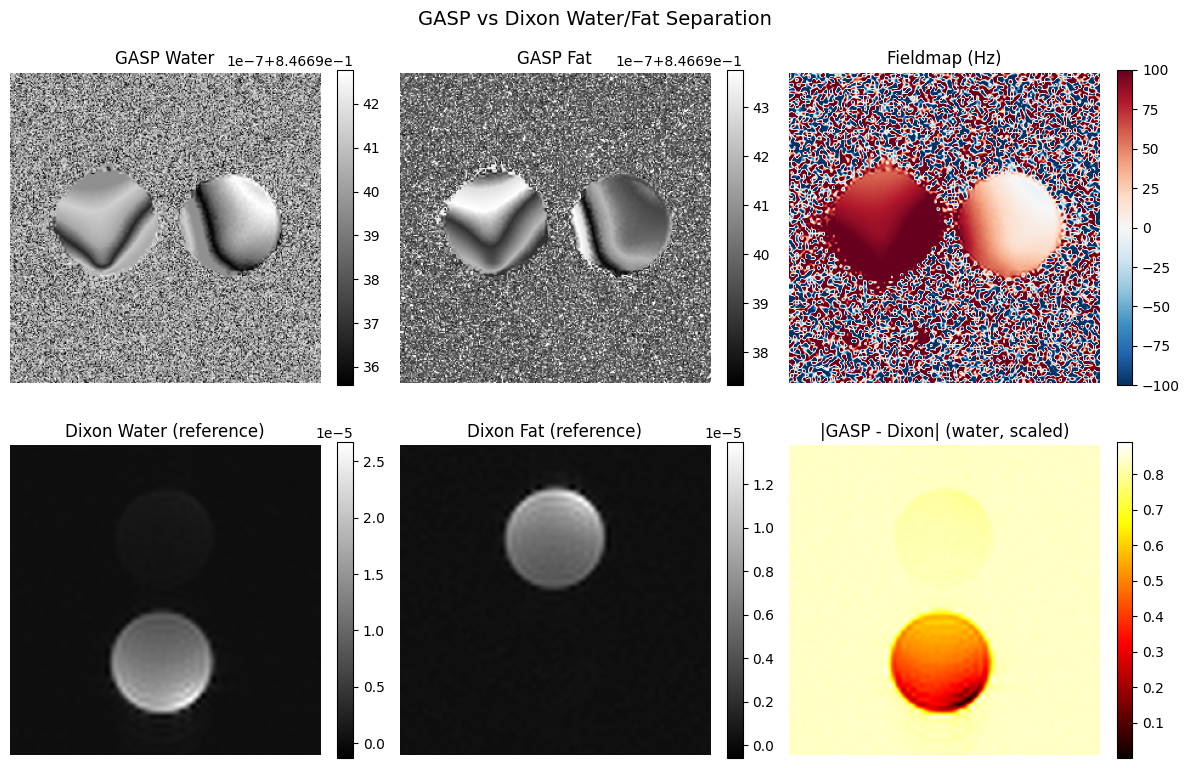

In [9]:
# Apply GASP with fieldmap compensation to real data
# M shape: (256, 256, 8, 16, 3) - (H, W, Coils, PCs, TRs)

# Extract data for TR=14ms (index 1) and combine coils
M_tr14 = M[:, :, :, :, TR_idx]  # (256, 256, 8, 16)

# Process each coil separately and combine
n_coils = M_tr14.shape[2]
water_per_coil = []
fat_per_coil = []

print("Applying GASP with fieldmap compensation...")
for coil in range(n_coils):
    coil_data = M_tr14[:, :, coil, :]  # (256, 256, 16)
    
    # Apply water dictionary
    water_coil = apply_gasp_with_fieldmap(
        data=coil_data,
        field_map=fieldmap_hz_interp,
        dictionary=dict_water,
        interpolation='linear'
    )
    water_per_coil.append(water_coil)
    
    # Apply fat dictionary  
    fat_coil = apply_gasp_with_fieldmap(
        data=coil_data,
        field_map=fieldmap_hz_interp,
        dictionary=dict_fat,
        interpolation='linear'
    )
    fat_per_coil.append(fat_coil)

# Coil combine with RSS
water_gasp = np.sqrt(np.sum(np.abs(np.array(water_per_coil))**2, axis=0))
fat_gasp = np.sqrt(np.sum(np.abs(np.array(fat_per_coil))**2, axis=0))

print(f"GASP water shape: {water_gasp.shape}")
print(f"GASP fat shape: {fat_gasp.shape}")

# Plot GASP results vs Dixon results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# GASP results (top row)
im0 = axes[0, 0].imshow(water_gasp, cmap='gray')
axes[0, 0].set_title('GASP Water')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(fat_gasp, cmap='gray')
axes[0, 1].set_title('GASP Fat')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[0, 2].imshow(fieldmap_hz_interp, cmap='RdBu_r', vmin=-100, vmax=100)
axes[0, 2].set_title('Fieldmap (Hz)')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Dixon results (bottom row) - interpolate to match GASP dimensions
water_dixon_interp = zoom(Mwater, (H / Mwater.shape[0], W / Mwater.shape[1]), order=3)
fat_dixon_interp = zoom(Mfat, (H / Mfat.shape[0], W / Mfat.shape[1]), order=3)

im3 = axes[1, 0].imshow(water_dixon_interp, cmap='gray')
axes[1, 0].set_title('Dixon Water (reference)')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

im4 = axes[1, 1].imshow(fat_dixon_interp, cmap='gray')
axes[1, 1].set_title('Dixon Fat (reference)')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

# Difference or correlation plot
im5 = axes[1, 2].imshow(np.abs(water_gasp - water_dixon_interp / water_dixon_interp.max() * water_gasp.max()), cmap='hot')
axes[1, 2].set_title('|GASP - Dixon| (water, scaled)')
axes[1, 2].axis('off')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

plt.suptitle('GASP vs Dixon Water/Fat Separation', fontsize=14)
plt.tight_layout()
plt.show()

For this i would like to use gasp with a fieldmap to separate the water from fat components using a targeted bandpass and a shifted bandpass. 